# **RFM Customer Segmentation**

## Problem Statement

In competitive markets, understanding customer behavior is critical.
This project applies RFM (Recency, Frequency, Monetary) analysis to segment customers and identify high-value groups.

---

## What is RFM?

RFM stands for **Recency, Frequency, and Monetary value** — three simple but powerful metrics that describe how a customer interacts with a business.

* **Recency (R):** How recently a customer made a purchase
* **Frequency (F):** How often they purchase
* **Monetary (M):** How much they spend

The idea behind RFM is straightforward:
customers who bought **recently**, **frequently**, and **spend more** are usually the most valuable.

Instead of treating all customers the same, RFM allows us to break them into groups based on actual behavior.

---

## Why RFM?

Many businesses struggle with questions like:

* Who are my best customers?
* Which users are about to churn?
* Where should I focus marketing efforts?

RFM provides a simple, interpretable way to answer these questions without needing complex models.

It is widely used because:

* It is easy to implement
* It does not require labeled data
* Results are directly actionable

---

## Objective

The main goal of this project is to use RFM analysis to:

* Identify meaningful customer segments
* Highlight high-value and loyal customers
* Detect customers at risk of churning
* Support more targeted and efficient marketing strategies

---

## Perspective

From a data science point of view, this can be seen as a **behavior-based segmentation problem**.
Although RFM itself is rule-based, it lays the foundation for more advanced approaches such as clustering and predictive modeling.


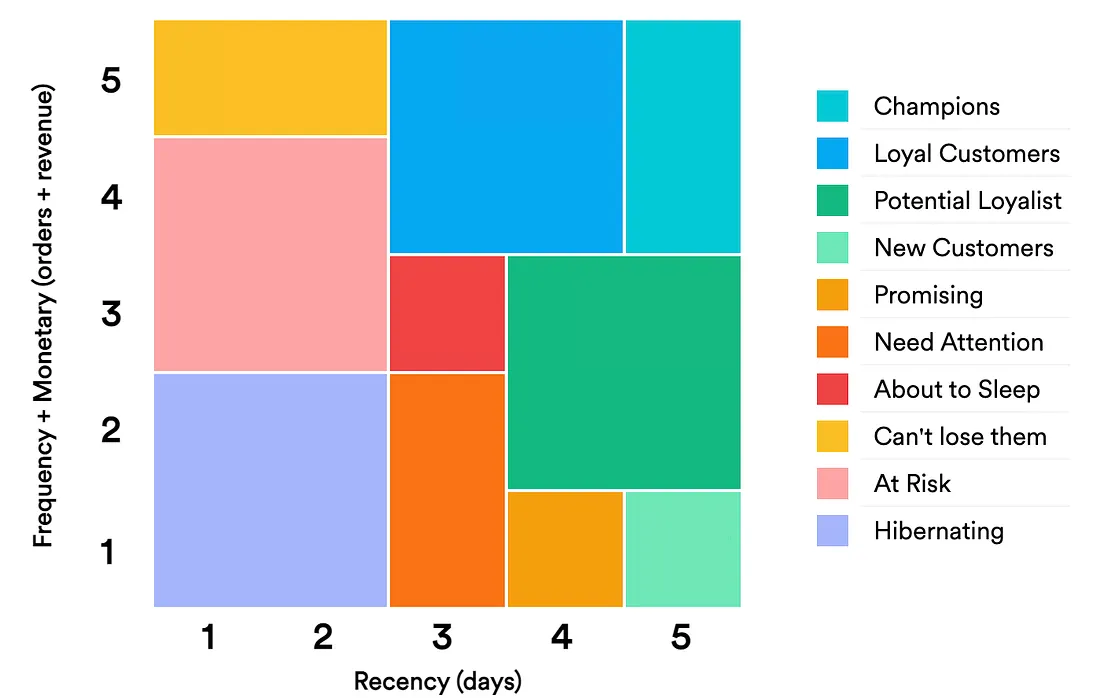

https://miro.medium.com/v2/resize:fit:1100/format:webp/1*kkahOuOo--oRkROosijziw.png

* Champions: Bought recently, buy often and spend the most
* Loyal customers: Buy on a regular basis. Responsive to promotions.
* Potential loyalist: Recent customers with average frequency.
* Recent customers: Bought most recently, but not often.
* Promising: Recent shoppers, but haven’t spent much.
* Needs attention: Above average recency, frequency and monetary values. May not have bought very recently though.
* About to sleep: Below average recency and frequency. Will lose them if not reactivated.
* At risk: Some time since they’ve purchased. Need to bring them back!
* Can’t lose them: Used to purchase frequently but haven’t returned for a long time.
* Hibernating: Last purchase was long back and low number of orders. May be lost.

## **1. Import Libraries and Load Dataset**

In [4]:
import pandas as pd
!pip install squarify
import matplotlib.pyplot as plt
import seaborn as sns
import squarify

In [5]:
df = pd.read_csv("marketing_campaign.csv", sep='\t')
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


## **2. RFM Score Calculation**

In [6]:
df['Total_Spending'] = df['MntWines'] + df['MntFruits'] \
                       + df['MntMeatProducts'] + df['MntFishProducts'] \
                       + df['MntSweetProducts'] + df['MntGoldProds']


df['Total_Num_Purchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] \
                             + df['NumStorePurchases'] + df['NumDealsPurchases']

In [7]:
rfm_df = df[["ID", "Recency"]].copy()
rfm_df["Frequency"] = df["Total_Num_Purchases"].copy()
rfm_df["Monetary"] = df["Total_Spending"].copy()
rfm_df.head(10)

,ID,Recency,Frequency,Monetary
0,5524,58,25,1617
1,2174,38,6,27
2,4141,26,21,776
3,6182,26,8,53
4,5324,94,19,422
5,7446,16,22,716
6,965,34,21,590
7,6177,32,10,169
8,4855,19,6,46
9,5899,68,2,49


- Recency: Lower is better → recent customers
- Frequency: Higher is better → loyal customers
- Monetary: Higher is better → valuable customers

In [8]:
rfm_df["R"] = pd.qcut(rfm_df["Recency"], 5, labels=[5,4,3,2,1])
rfm_df["F"] = pd.qcut(rfm_df["Frequency"], 5, labels=[1,2,3,4,5])
rfm_df["M"] = pd.qcut(rfm_df["Monetary"], 5, labels=[1,2,3,4,5])

rfm_df["RFM_SCORE"] = (rfm_df['R'].astype(str)
                    + rfm_df['F'].astype(str)
                    + rfm_df['M'].astype(str))

rfm_df["RF_SCORE"] = (rfm_df['R'].astype(str) + rfm_df['F'].astype(str))

rfm_df.head(10)

,ID,Recency,Frequency,Monetary,R,F,M,RFM_SCORE,RF_SCORE
0,5524,58,25,1617,3,5,5,355,35
1,2174,38,6,27,4,1,1,411,41
2,4141,26,21,776,4,4,4,444,44
3,6182,26,8,53,4,2,1,421,42
4,5324,94,19,422,1,4,3,143,14
5,7446,16,22,716,5,4,4,544,54
6,965,34,21,590,4,4,3,443,44
7,6177,32,10,169,4,2,2,422,42
8,4855,19,6,46,5,1,1,511,51
9,5899,68,2,49,2,1,1,211,21


## **3. Customer Segmentation Based on RFM Scores**

In [9]:
seg_map = {
    r'[1-2][1-2]': 'hibernating',
    r'[1-2][3-4]': 'at_Risk',
    r'[1-2]5': 'cant_loose',
    r'3[1-2]': 'about_to_sleep',
    r'33': 'need_attention',
    r'[3-4][4-5]': 'loyal_customers',
    r'41': 'promising',
    r'51': 'new_customers',
    r'[4-5][2-3]': 'potential_loyalists',
    r'5[4-5]': 'champions'
}

rfm_df['segment'] = rfm_df['RF_SCORE'].replace(seg_map, regex=True)

In [10]:
rfm_df.groupby('segment').agg({
    'Recency': ['mean', 'min', 'max'],
    'Frequency': ['mean', 'min', 'max'],
    'Monetary': ['mean', 'min', 'max'],
})

Recency          Frequency             Monetary       \
                          mean min max       mean min max         mean  min   
segment                                                                       
about_to_sleep       49.377049  40  59   6.852459   0  11    77.338798    5   
at_Risk              78.586842  60  99  17.465789  12  22   877.692105    8   
cant_loose           80.062893  60  99  25.981132  23  39  1205.918239  416   
champions             9.194118   0  19  22.905882  18  35  1062.176471  277   
hibernating          80.162319  60  99   7.031884   0  11    83.857971    6   
loyal_customers      39.900850  20  59  23.178470  18  44  1115.923513  279   
need_attention       50.116279  40  59  14.953488  12  17   657.779070   53   
new_customers         9.491525   0  19   5.381356   1   7    47.703390    8   
potential_loyalists  19.014837   0  39  12.646884   8  17   438.142433    9   
promising            29.669725  20  39   5.357798   0   7    39.422018    6   

                           
                      max  
segment                    
about_to_sleep       1679  
at_Risk              2302  
cant_loose           2524  
champions            2349  
hibernating          1511  
loyal_customers      2525  
need_attention       2231  
new_customers         373  
potential_loyalists  1932  
promising             107

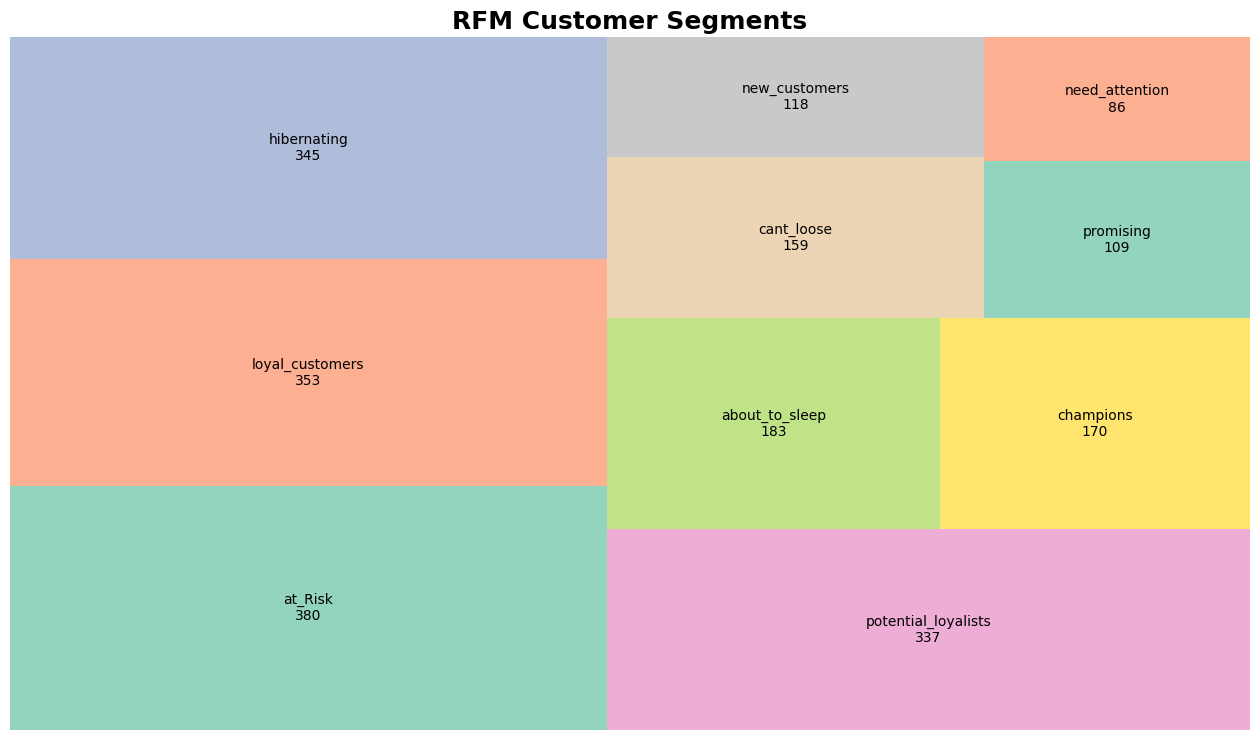

In [11]:
def squarify_segments(dataframe, segment_col, show_value=False):
    sort_segment = dataframe[segment_col].value_counts().sort_values(ascending=False)

    plt.figure(figsize=(16,9))
    labels = [f'{seg}\n{cnt}' if show_value else seg for seg, cnt in zip(sort_segment.index, sort_segment.values)]

    squarify.plot(sizes=sort_segment.values,
                  label=labels,
                  alpha=0.7,
                  color=sns.color_palette("Set2", len(sort_segment)))
    plt.title("RFM Customer Segments", fontsize=18, fontweight='bold')
    plt.axis('off')
    plt.show()

squarify_segments(rfm_df, segment_col='segment', show_value=True)

Pareto Principle (80/20 Rule)
* The Pareto Principle states that roughly 80% of effects come from 20% of causes.
* In business terms:
  - 80% of revenue often comes from 20% of customers.
  - 80% of complaints come from 20% of product issues, etc.

Applied to RFM customer segmentation:
* A small number of high-value segments (like Champions or Loyal Customers) usually account for most of your sales or interactions.
* Low-value segments (like Hibernating or At Risk) often contribute less but may have potential if targeted correctly.

/tmp/ipykernel_5331/1243810072.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette="Set2", ax=ax1)


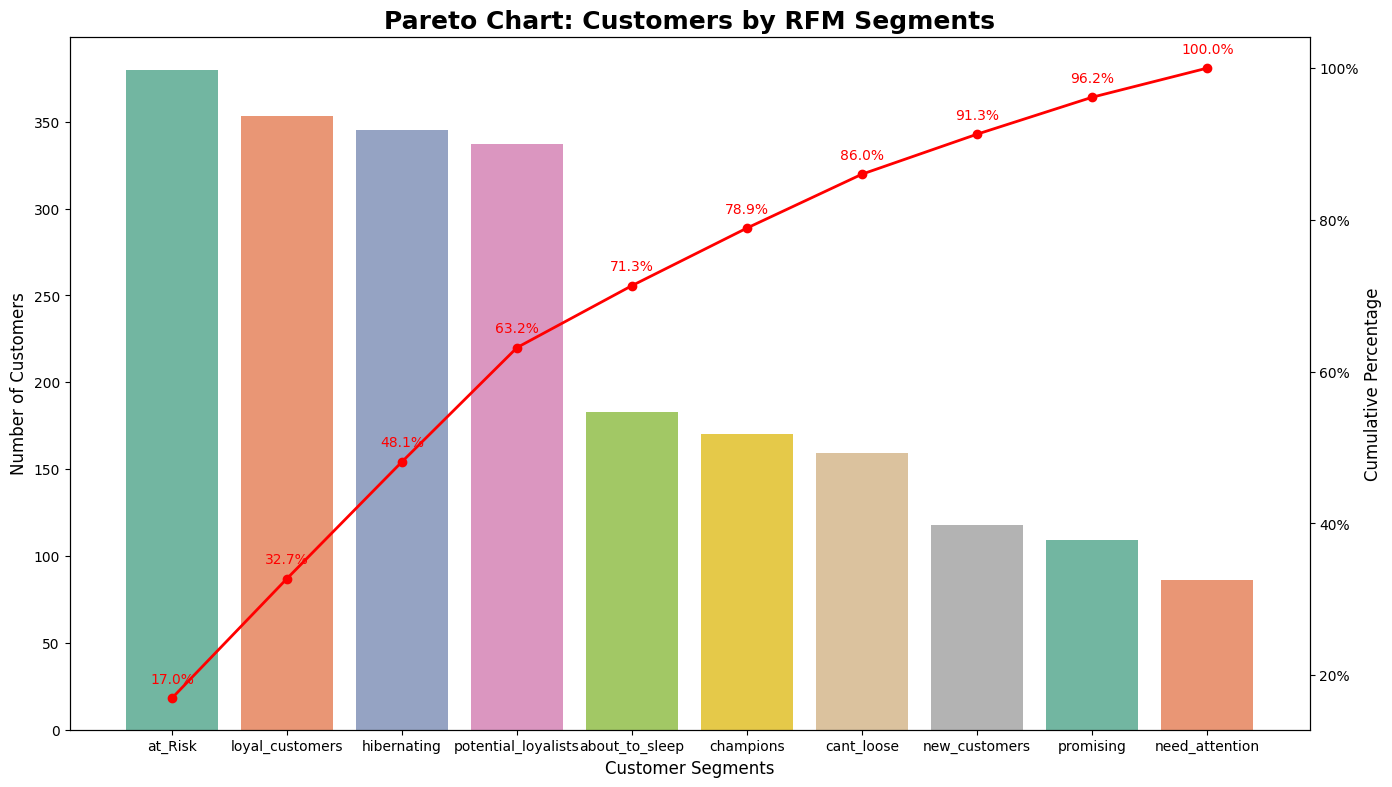

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Compute counts per segment and sort descending
segment_counts = rfm_df['segment'].value_counts().sort_values(ascending=False)

# Compute cumulative percentage
cumulative_pct = segment_counts.cumsum() / segment_counts.sum() * 100

# Create figure
fig, ax1 = plt.subplots(figsize=(16,9))

# Bar chart for segment counts
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette="Set2", ax=ax1)
ax1.set_ylabel('Number of Customers', fontsize=12)
ax1.set_xlabel('Customer Segments', fontsize=12)
ax1.set_title('Pareto Chart: Customers by RFM Segments', fontsize=18, fontweight='bold')

# Line chart for cumulative percentage
ax2 = ax1.twinx()  # secondary y-axis
ax2.plot(segment_counts.index, cumulative_pct, color='red', marker='o', linewidth=2)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax2.set_ylabel('Cumulative Percentage', fontsize=12)

# Annotate cumulative percentages on line
for i, pct in enumerate(cumulative_pct):
    ax2.text(i, pct+2, f'{pct:.1f}%', color='red', ha='center')

plt.show()


## **4. Further**

Actionable Insights (Marketing & Retention)

For each segment, decide what business action is appropriate

| Segment             | Action                                          |
| ------------------- | ----------------------------------------------- |
| Champions           | Reward / loyalty programs to retain & upsell    |
| Loyal Customers     | Encourage referrals / cross-sell products       |
| Potential Loyalists | Engage with personalized offers to become loyal |
| Promising           | Upsell to increase frequency & spending         |
| At Risk             | Re-engage with win-back campaigns               |
| Hibernating         | Long-term nurturing / retention campaigns       |
| About to Sleep      | Send reminders / incentives to prevent churn    |
| Need Attention      | Monitor closely, may become active again        |
| New Customers       | Onboard & educate, encourage repeat purchases   |
| Can't Lose          | Special offers to retain (high churn risk)      |


Advanced Analysis (Optional / Next-Level)

* RFM + Demographics / Customer Profiles
  - Age, gender, location, products purchased → understand who is in each segment.

* Time-based trends
  - Segment evolution over time → are some segments shrinking / growing?

* Predictive modeling
  - Use RFM as features to predict next purchase, churn, or CLV (Customer Lifetime Value).

* Cluster segments further
  - RFM may be coarse → use KMeans or hierarchical clustering on Recency, Frequency, Monetary for nuanced segmentation.